/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


reading mocks


/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=100 in 0.831 sec


/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=110 in 0.636 sec


/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=111 in 0.686 sec
finished all runs in 2.153 sec
fraction of mocks with true minimum 0.3 0.62 0.95
saved /mnt/ceph/users/vpandya/sapphire_outputs/figures/coverage_adam_predicted_vs_true_parameters.png


/mnt/ceph/users/vpandya/sapphire/sapphire/visualization/adam_coverage.py:233: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(par_labels, rotation=0,fontsize=12)
/mnt/ceph/users/vpandya/sapphire/sapphire/visualization/adam_coverage.py:233: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(par_labels, rotation=0,fontsize=12)


saved /mnt/ceph/users/vpandya/sapphire_outputs/figures/coverage_adam_summaries.png


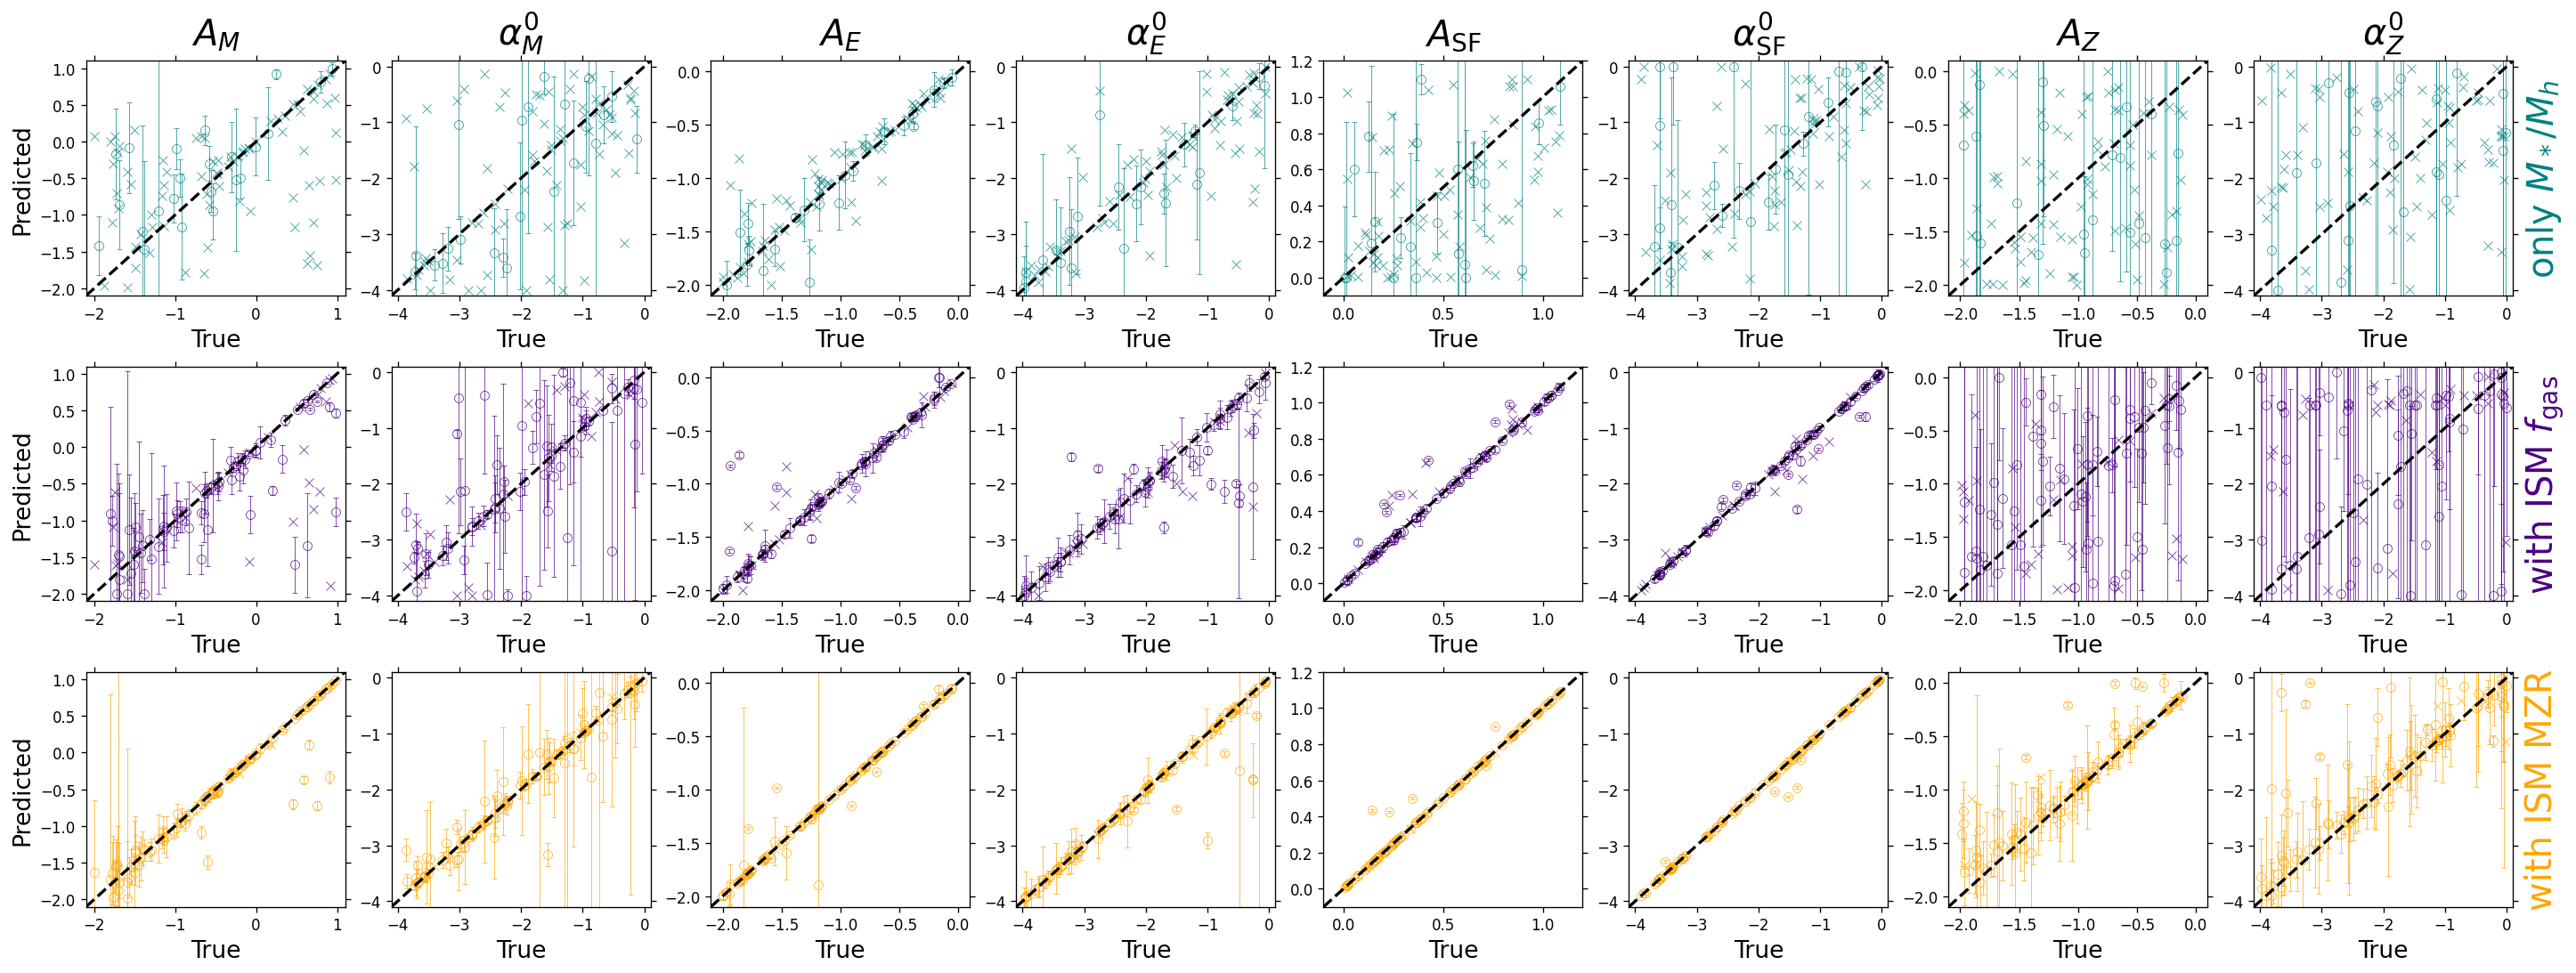

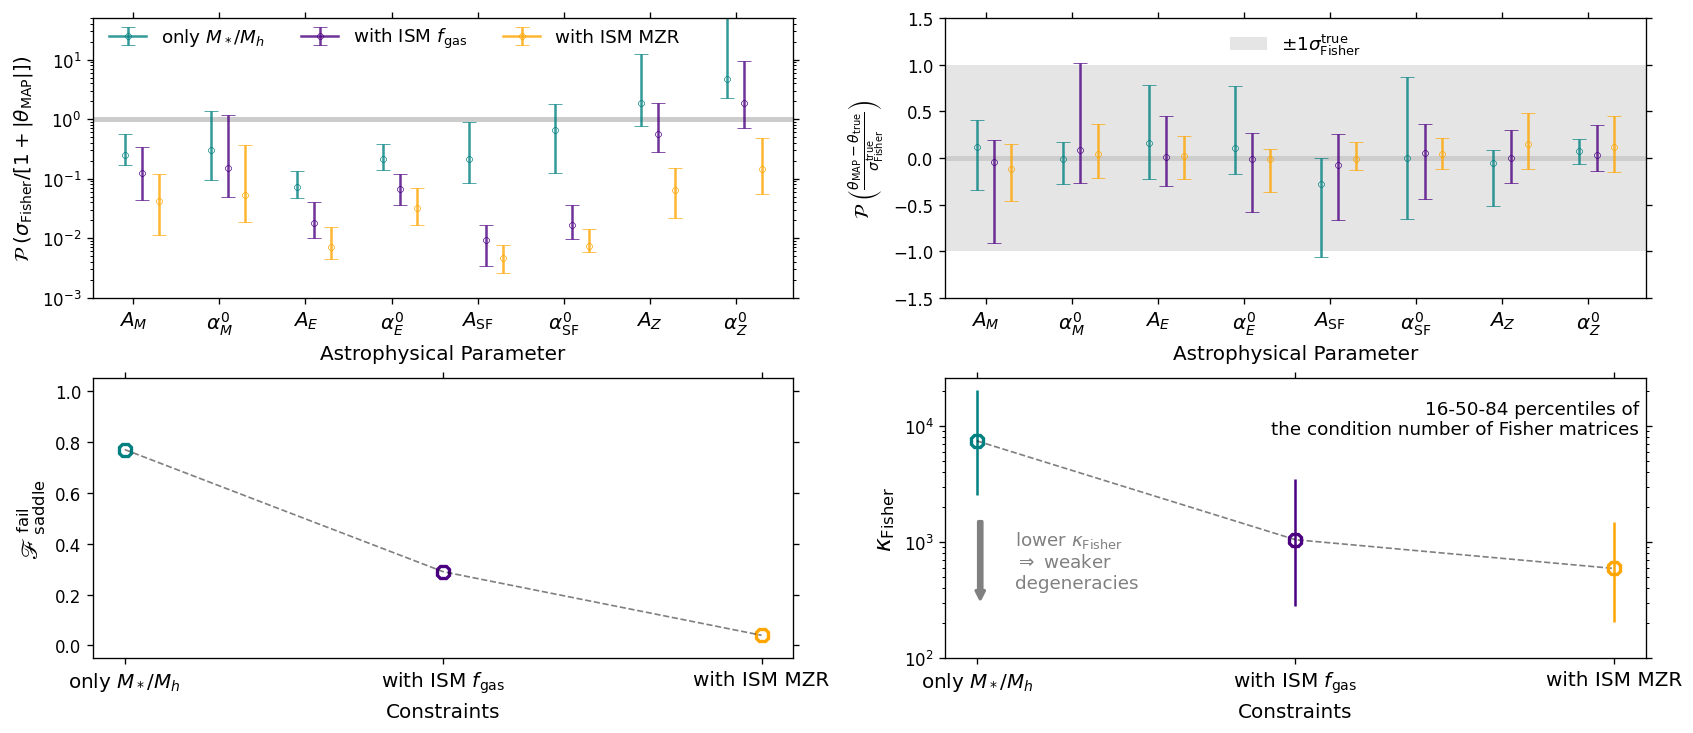

In [1]:
from sapphire import visualization
import jax.numpy as jnp

output_path = '/mnt/ceph/users/vpandya/sapphire_outputs'
mocknums = jnp.arange(100)
constraint_flags = ['100','110','111']
constraint_labels = [r'only $M_*/M_h$',r'with ISM $f_{\rm gas}$',r'with ISM MZR']
constraint_colors = ['teal','indigo','orange']
par_labels = [r'$A_M$',r'$\alpha_M^0$',r'$A_E$',r'$\alpha_E^0$',r'$A_{\rm SF}$',r'$\alpha_{\rm SF}^0$',r'$A_Z$',r'$\alpha_Z^0$']
suffix = '' # noise-free

visualization.adam_coverage.plot(output_path,mocknums,constraint_flags,constraint_labels,constraint_colors,par_labels,suffix,True)

# manually plot error forecasts outside of sapphire/visualization

In [36]:
%matplotlib inline
# plot-specific modules
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import arviz as az
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from chainconsumer import Chain, ChainConsumer, make_sample, PlotConfig, Truth, ChainConfig
plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

from astropy import constants as const
from astropy import units as u
from astropy.cosmology import Planck15
from functools import partial 
import multiprocess
from timeit import default_timer as timer
import os

# in case user loads module separately from sapphire.run()
from jax import config as jax_config
jax_config.update("jax_enable_x64", True) # required to accurately solve and take gradients through our diffeqs 

import jax
import jax.numpy as jnp
from jax._src.third_party.scipy.interpolate import RegularGridInterpolator as jax_RegularGridInterpolator
from jax import jit, grad, vmap, pmap, debug, jvp, vjp, jacrev, jacfwd, make_jaxpr, hessian, value_and_grad
from jax_cosmo.scipy.interpolate import InterpolatedUnivariateSpline    
from jax.experimental.ode import odeint
from jax.lax import fori_loop, while_loop
from jax.scipy.integrate import trapezoid
from jax.random import PRNGKey, key    
from diffrax import diffeqsolve, ODETerm, PIDController, SaveAt, Kvaerno3, Bosh3, Dopri5, Tsit5, DirectAdjoint, RecursiveCheckpointAdjoint, BacksolveAdjoint
from diffrax import backward_hermite_coefficients, CubicInterpolation    
from jax.experimental import mesh_utils
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, PartitionSpec, NamedSharding

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, AIES, ESS

import numpy as np # for np.ravel(axes), can probably be done away with

In [37]:
Npars = len(par_labels)

### nested function that returns trace_df and final point estimate +/- fisher sigma for each of the 3 constraints
def read_mocks(mocknum):

    # TO DO: have constraint_flag (and par_labels) be an input (compatible with multiprocess.map)
    # March 10 -- add suffix
    fname = os.path.join(output_path,'outputs','mock%s_%s%s.npz'%(mocknum,constraint_flag,suffix))

    npz = np.load(fname,allow_pickle=True)

    # best adam parameters
    mus = npz['theta_map']
    
    ### sqrt of inverse Fisher matrix diagonals
    Finv = npz['Finv_adam']

    # May 22: deal with when Finv_adam = nan due to saddle
    ### June 3 -- add correlation coefficient for off-diagonal degeneracies of Fisher
    try:
        sigmas = np.sqrt(np.diag(Finv))
        corr_matrix = Finv / np.outer(sigmas,sigmas)
    except:
        sigmas = np.full((Npars,), np.nan)
        corr_matrix = np.full((Npars, Npars), np.nan)        

    # mock truth parameter values
    truths = npz['free_params_arr']

    ### sqrt diagonals of TRUE Fisher -- this is what we normalize theta_map-theta_true by 
    Finv_true = npz['Finv_true']

    try: 
        sigmas_true = np.sqrt(np.diag(Finv_true))
    except:
        sigmas_true = np.full((Npars,), np.nan)

    # July 8 -- ratio of best loss from adam / true loss, note this includes saddles but we can filter later 
    # actually since these are negative log-posteriors, makes more sense to subtract best minus true 
    loss_ratio = float(npz['best_adam_loss']) - float(npz['true_loss'])

    # filter here -- set loss ratio to nan for saddles for plotting/nan-averaging purposes
    if not np.all(np.isfinite(sigmas)):
        loss_ratio = np.nan
    
    # return trace_dfs, mus, sigmas, truths
    return mus, sigmas, truths, sigmas_true, corr_matrix, loss_ratio




In [38]:
### read and group mocks, labels, etc. for plotting

# globals for read_mocks
constraint_flag = '111'

# set of N mockerr datasets to plot
suffixes = ['_slope4_mzrgas_mockerrs','_slope4_mzrgas_mockerrshalf','_slope4_mzrgas_mockerrstenth'] 
mockerr_labels = [r'$\sigma_{\rm obs}$',r'$\sigma_{\rm obs}/2$',r'$\sigma_{\rm obs}/10$'] 

out_constraint_mockerrs = [] 

tstart0 = timer() 
for suffix in suffixes:

    print('reading in %s'%suffix,flush=True)

    with multiprocess.Pool(40) as pool:
        out_constraint_mockerrs.append(pool.map(read_mocks, mocknums))

print('finished in %.2f sec'%(timer()-tstart0))

reading in _slope4_mzrgas_mockerrs


/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


reading in _slope4_mzrgas_mockerrshalf


/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


reading in _slope4_mzrgas_mockerrstenth


/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished in 2.11 sec


In [39]:
#### note should just use the imported versions of these from sapphire.visualization

def percentile_fishers(sigmas,mus):

    # apply mask 
    mask = np.isfinite(sigmas)
    masked_sigmas = sigmas[mask]

    # March 10 -- normalize parameter value (mu) to get fractional uncertainty
    masked_mus = mus[mask]
    masked_fracs = masked_sigmas / (1+jnp.abs(masked_mus)) # abs value needed since many parameters can be negative 

    # compute percentiles of masked sigmas 
    p16_sigmas = np.nanpercentile(masked_fracs,16,axis=0) 
    p50_sigmas = np.nanpercentile(masked_fracs,50,axis=0) 
    p84_sigmas = np.nanpercentile(masked_fracs,84,axis=0) 
    
    return p16_sigmas, p50_sigmas, p84_sigmas  

def percentile_biases(mus,truths,sigmas_true):

    # accuracy/bias statistic 
    biases = (mus-truths)/(sigmas_true)
    
    # apply mask 
    mask = np.isfinite(sigmas_true) # should always be defined for truth but just in case
    masked_sigmas = sigmas_true[mask]
    masked_biases = biases[mask]
    
    # compute percentiles of masked sigmas 
    p16_biases = np.nanpercentile(masked_biases,16,axis=0)
    p50_biases = np.nanpercentile(masked_biases,50,axis=0)
    p84_biases = np.nanpercentile(masked_biases,84,axis=0)
    
    return p16_biases, p50_biases, p84_biases


def compute_f_fail(out_run):
    sigmas = out_run[:,1,:]
    Nfail = np.sum(~np.all(np.isfinite(sigmas),axis=1))
    return Nfail/len(sigmas)


def fisher_cond(corr_matrices):
    # cond # only computed if an individual realizations' fisher matrix is not nan's (which happens when adam didn't converge to minimum)
    conds = np.asarray([np.linalg.cond(corr_matrices[i]) if np.isfinite(corr_matrices[i]).all() else np.nan for i in range(len(corr_matrices))])
    return np.nanpercentile(conds,16),np.nanpercentile(conds,50),np.nanpercentile(conds,84)


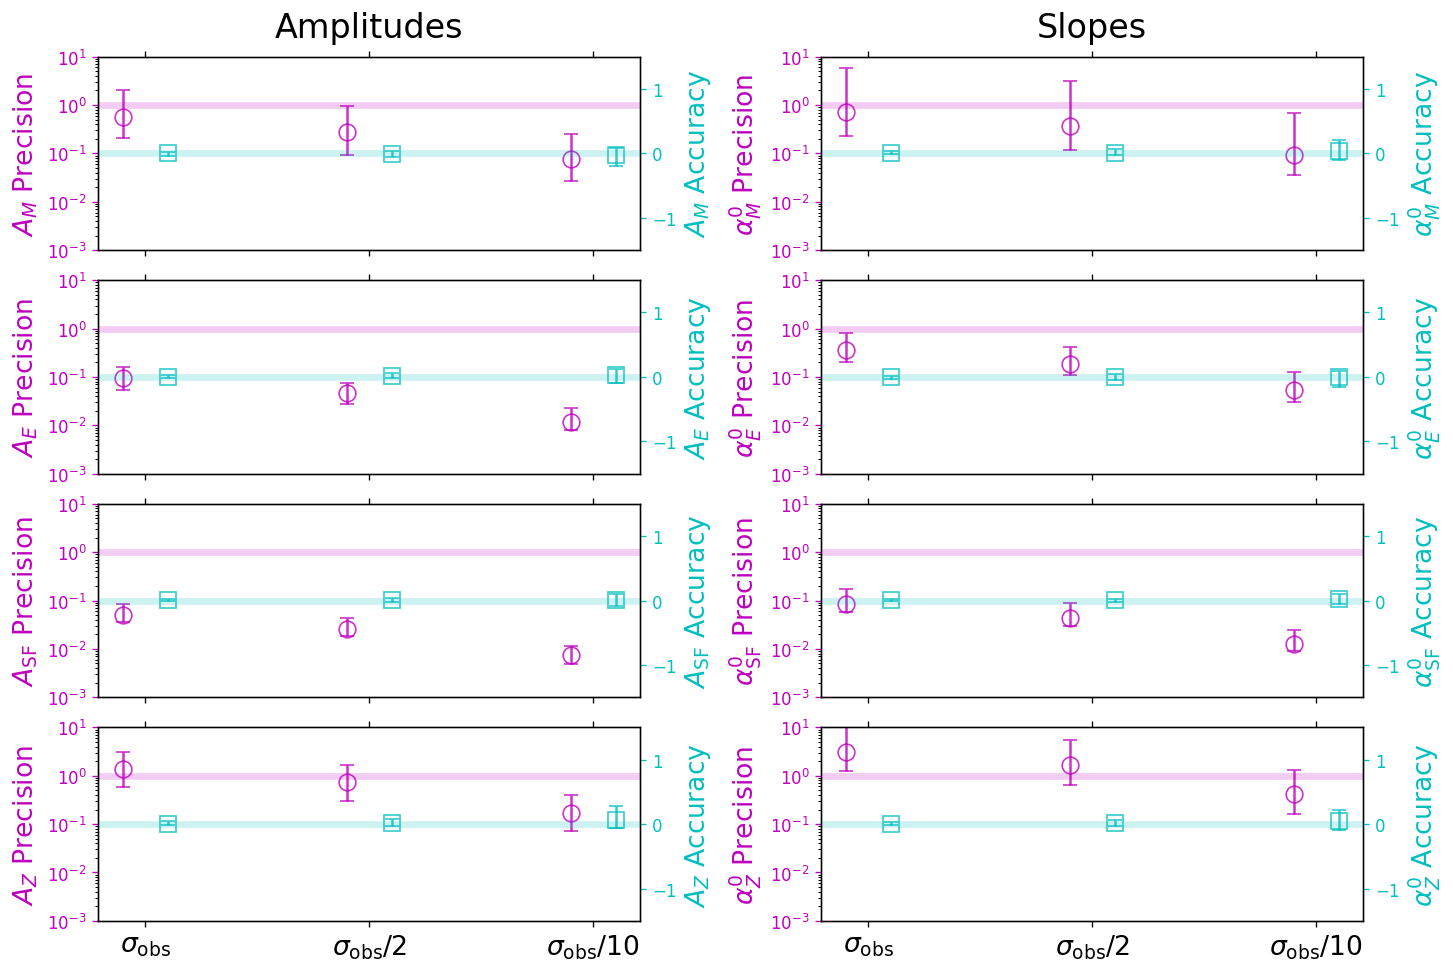

In [45]:
fig, axes = plt.subplots(nrows=4,ncols=2,figsize=(12,8),sharex=True,constrained_layout=True)

allax = axes.flatten()

ax_precision = []
ax_accuracy = []

# Define x positions for the x-labels (sigma_obs)
xvals = np.arange(len(mockerr_labels))
shift = 0.1 # shift precision and accuracy points left/right

# this loop over axnums is also over parameters 
for axnum,ax in enumerate(allax):

    ax_p = ax
    ax_a = ax.twinx()

    ### loop over the different mockerrs to plot for this parameter
    for out_num,out_mockerr in enumerate(out_constraint_mockerrs):
        mockerr_label = mockerr_labels[out_num]

        constraint_result = np.asarray([out_mockerr[i][:4] for i in mocknums]) 

        p16, p50, p84 = percentile_fishers(constraint_result[:, 1, axnum],constraint_result[:, 0, axnum]) 
        ax_p.errorbar(xvals[out_num]-shift, float(p50), 
                              yerr=[[p50 - p16], [p84 - p50]],
                              fmt='-o',color='m',
                              capsize=4, lw=1.5, alpha=0.8, mfc='none',
                              ms=10, mew=1,label=mockerr_label if axnum == 0 else '__none__') 
    
        ### accuracy (bias) 
        p16, p50, p84 = percentile_biases(constraint_result[:, 0, axnum],constraint_result[:, 2, axnum],constraint_result[:, 3, axnum]) 
        ax_a.errorbar(xvals[out_num]+shift, float(p50),
                             yerr=[[p50 - p16], [p84 - p50]],
                             fmt='-s',color='c',
                             capsize=4, lw=1.5, alpha=0.8, mfc='none',
                             ms=10, mew=1,label='__none__') 

    ### global properties for this panel/parameter
    ax_p.set_xticks(xvals)
    ax_p.set_xticklabels(mockerr_labels, rotation=0,fontsize=16)

    ax_p.set_ylabel(r'%s Precision'%(par_labels[axnum]),fontsize=16,color='m')
    ax_a.set_ylabel(r'%s Accuracy'%(par_labels[axnum]),fontsize=16,color='c')

    ax_p.tick_params(axis='y', colors='m')
    ax_a.tick_params(axis='y', colors='c')   

    ax_p.set_yscale('log')
    ax_p.set_ylim(1e-3,1e1)
    ax_p.axhline(1.0,color='m',ls='-',lw=4,alpha=0.2)

    # ax_a.set_yscale('symlog',linthresh=1e-1)
    ax_a.set_ylim(-1.5, 1.5)
    ax_a.axhline(0.0, color='c', ls='-', alpha=0.2, zorder=0, lw=4)    

    ax_precision.append(ax_p)
    ax_accuracy.append(ax_a)

allax[0].set_title('Amplitudes',fontsize=20,y=1.05)
allax[1].set_title('Slopes',fontsize=20,y=1.05)

# plt.savefig('/mnt/ceph/users/vpandya/sapphire_outputs/figures/coverage_adam_precision_accuracy_mockerrs.png',
#             bbox_inches='tight',dpi=300,facecolor='w')

# 2x2 version of summary figure 

# figure showing all 7 data combos

In [2]:
%matplotlib inline

# plot-specific modules
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import arviz as az
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from chainconsumer import Chain, ChainConsumer, make_sample, PlotConfig, Truth, ChainConfig
plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

from astropy import constants as const
from astropy import units as u
from astropy.cosmology import Planck15
from functools import partial 
import multiprocess
from timeit import default_timer as timer
import os

# in case user loads module separately from sapphire.run()
from jax import config as jax_config
jax_config.update("jax_enable_x64", True) # required to accurately solve and take gradients through our diffeqs 

import jax
import jax.numpy as jnp
from jax._src.third_party.scipy.interpolate import RegularGridInterpolator as jax_RegularGridInterpolator
from jax import jit, grad, vmap, pmap, debug, jvp, vjp, jacrev, jacfwd, make_jaxpr, hessian, value_and_grad
from jax_cosmo.scipy.interpolate import InterpolatedUnivariateSpline    
from jax.experimental.ode import odeint
from jax.lax import fori_loop, while_loop
from jax.scipy.integrate import trapezoid
from jax.random import PRNGKey, key    
from diffrax import diffeqsolve, ODETerm, PIDController, SaveAt, Kvaerno3, Bosh3, Dopri5, Tsit5, DirectAdjoint, RecursiveCheckpointAdjoint, BacksolveAdjoint
from diffrax import backward_hermite_coefficients, CubicInterpolation    
from jax.experimental import mesh_utils
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, PartitionSpec, NamedSharding

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, AIES, ESS

import numpy as np # for np.ravel(axes), can probably be done away with

In [3]:
output_path = '/mnt/ceph/users/vpandya/sapphire_outputs'
mocknums = jnp.arange(100)
constraint_flags = ['100','110','111','101','010','001','011']
# constraint_labels = [r'only $M_*/M_h$',r'with ISM $f_{\rm gas}$',r'with ISM MZR']
constraint_labels = [r'SMHM','SMHM+gas',r'SMHM+gas+MZR','SMHM+MZR','gas','MZR','gas+MZR']
constraint_colors = ['teal','indigo','orange','springgreen','hotpink','turquoise','lightcoral']
par_labels = [r'$A_M$',r'$\alpha_M^0$',r'$A_E$',r'$\alpha_E^0$',r'$A_{\rm SF}$',r'$\alpha_{\rm SF}^0$',r'$A_Z$',r'$\alpha_Z^0$']
Npars = len(par_labels)

suffix = '' # noise-free

In [4]:
### nested function that returns trace_df and final point estimate +/- fisher sigma for each of the 3 constraints
def read_mocks(mocknum):

    # TO DO: have constraint_flag (and par_labels) be an input (compatible with multiprocess.map)
    # March 10 -- add suffix
    fname = os.path.join(output_path,'outputs','mock%s_%s%s.npz'%(mocknum,constraint_flag,suffix))

    npz = np.load(fname,allow_pickle=True)

    # best adam parameters
    mus = npz['theta_map']
    
    ### sqrt of inverse Fisher matrix diagonals
    Finv = npz['Finv_adam']

    # May 22: deal with when Finv_adam = nan due to saddle
    ### June 3 -- add correlation coefficient for off-diagonal degeneracies of Fisher
    try:
        sigmas = np.sqrt(np.diag(Finv))
        corr_matrix = Finv / np.outer(sigmas,sigmas)
    except:
        sigmas = np.full((Npars,), np.nan)
        corr_matrix = np.full((Npars, Npars), np.nan)        

    # mock truth parameter values
    truths = npz['free_params_arr']

    ### sqrt diagonals of TRUE Fisher -- this is what we normalize theta_map-theta_true by 
    Finv_true = npz['Finv_true']

    try: 
        sigmas_true = np.sqrt(np.diag(Finv_true))
    except:
        sigmas_true = np.full((Npars,), np.nan)

    # July 8 -- ratio of best loss from adam / true loss, note this includes saddles but we can filter later 
    # actually since these are negative log-posteriors, makes more sense to subtract best minus true 
    loss_ratio = float(npz['best_adam_loss']) - float(npz['true_loss'])

    # filter here -- set loss ratio to nan for saddles for plotting/nan-averaging purposes
    if not np.all(np.isfinite(sigmas)):
        loss_ratio = np.nan
    
    # return trace_dfs, mus, sigmas, truths
    return mus, sigmas, truths, sigmas_true, corr_matrix, loss_ratio




In [5]:
### loop over and store outputs with multiprocess
constraint_results = []
constraint_corrs = []
constraint_Lratios = [] # loss ratios best_adam/true_loss

print('reading mocks',flush=True)
tstart0 = timer()

for constraint_num,constraint_flag in enumerate(constraint_flags):
    
    tstart = timer()
    with multiprocess.Pool(40) as pool:
        # shape (Nmocks, 3 [mus/sigmas/truths], Nparams)
        
        out_constraint = pool.map(read_mocks, mocknums)
        constraint_results.append(np.asarray([out_constraint[i][:4] for i in mocknums]))
        constraint_corrs.append(np.asarray([out_constraint[i][4] for i in mocknums]))
        constraint_Lratios.append(np.asarray([out_constraint[i][5] for i in mocknums]))
        
    print('finished constraint_flag=%s in %.3f sec'%(constraint_flag,timer()-tstart))

print('finished all runs in %.3f sec'%(timer()-tstart0))

reading mocks


/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=100 in 0.460 sec


/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=110 in 0.446 sec


...

finished constraint_flag=010 in 0.630 sec


/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=001 in 0.639 sec


/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=011 in 0.633 sec
finished all runs in 3.905 sec


In [6]:
from matplotlib.patches import Rectangle
from matplotlib.transforms import Bbox

saved /mnt/ceph/users/vpandya/sapphire_outputs/figures/coverage_adam_predicted_vs_true_parameters_allcombos.png


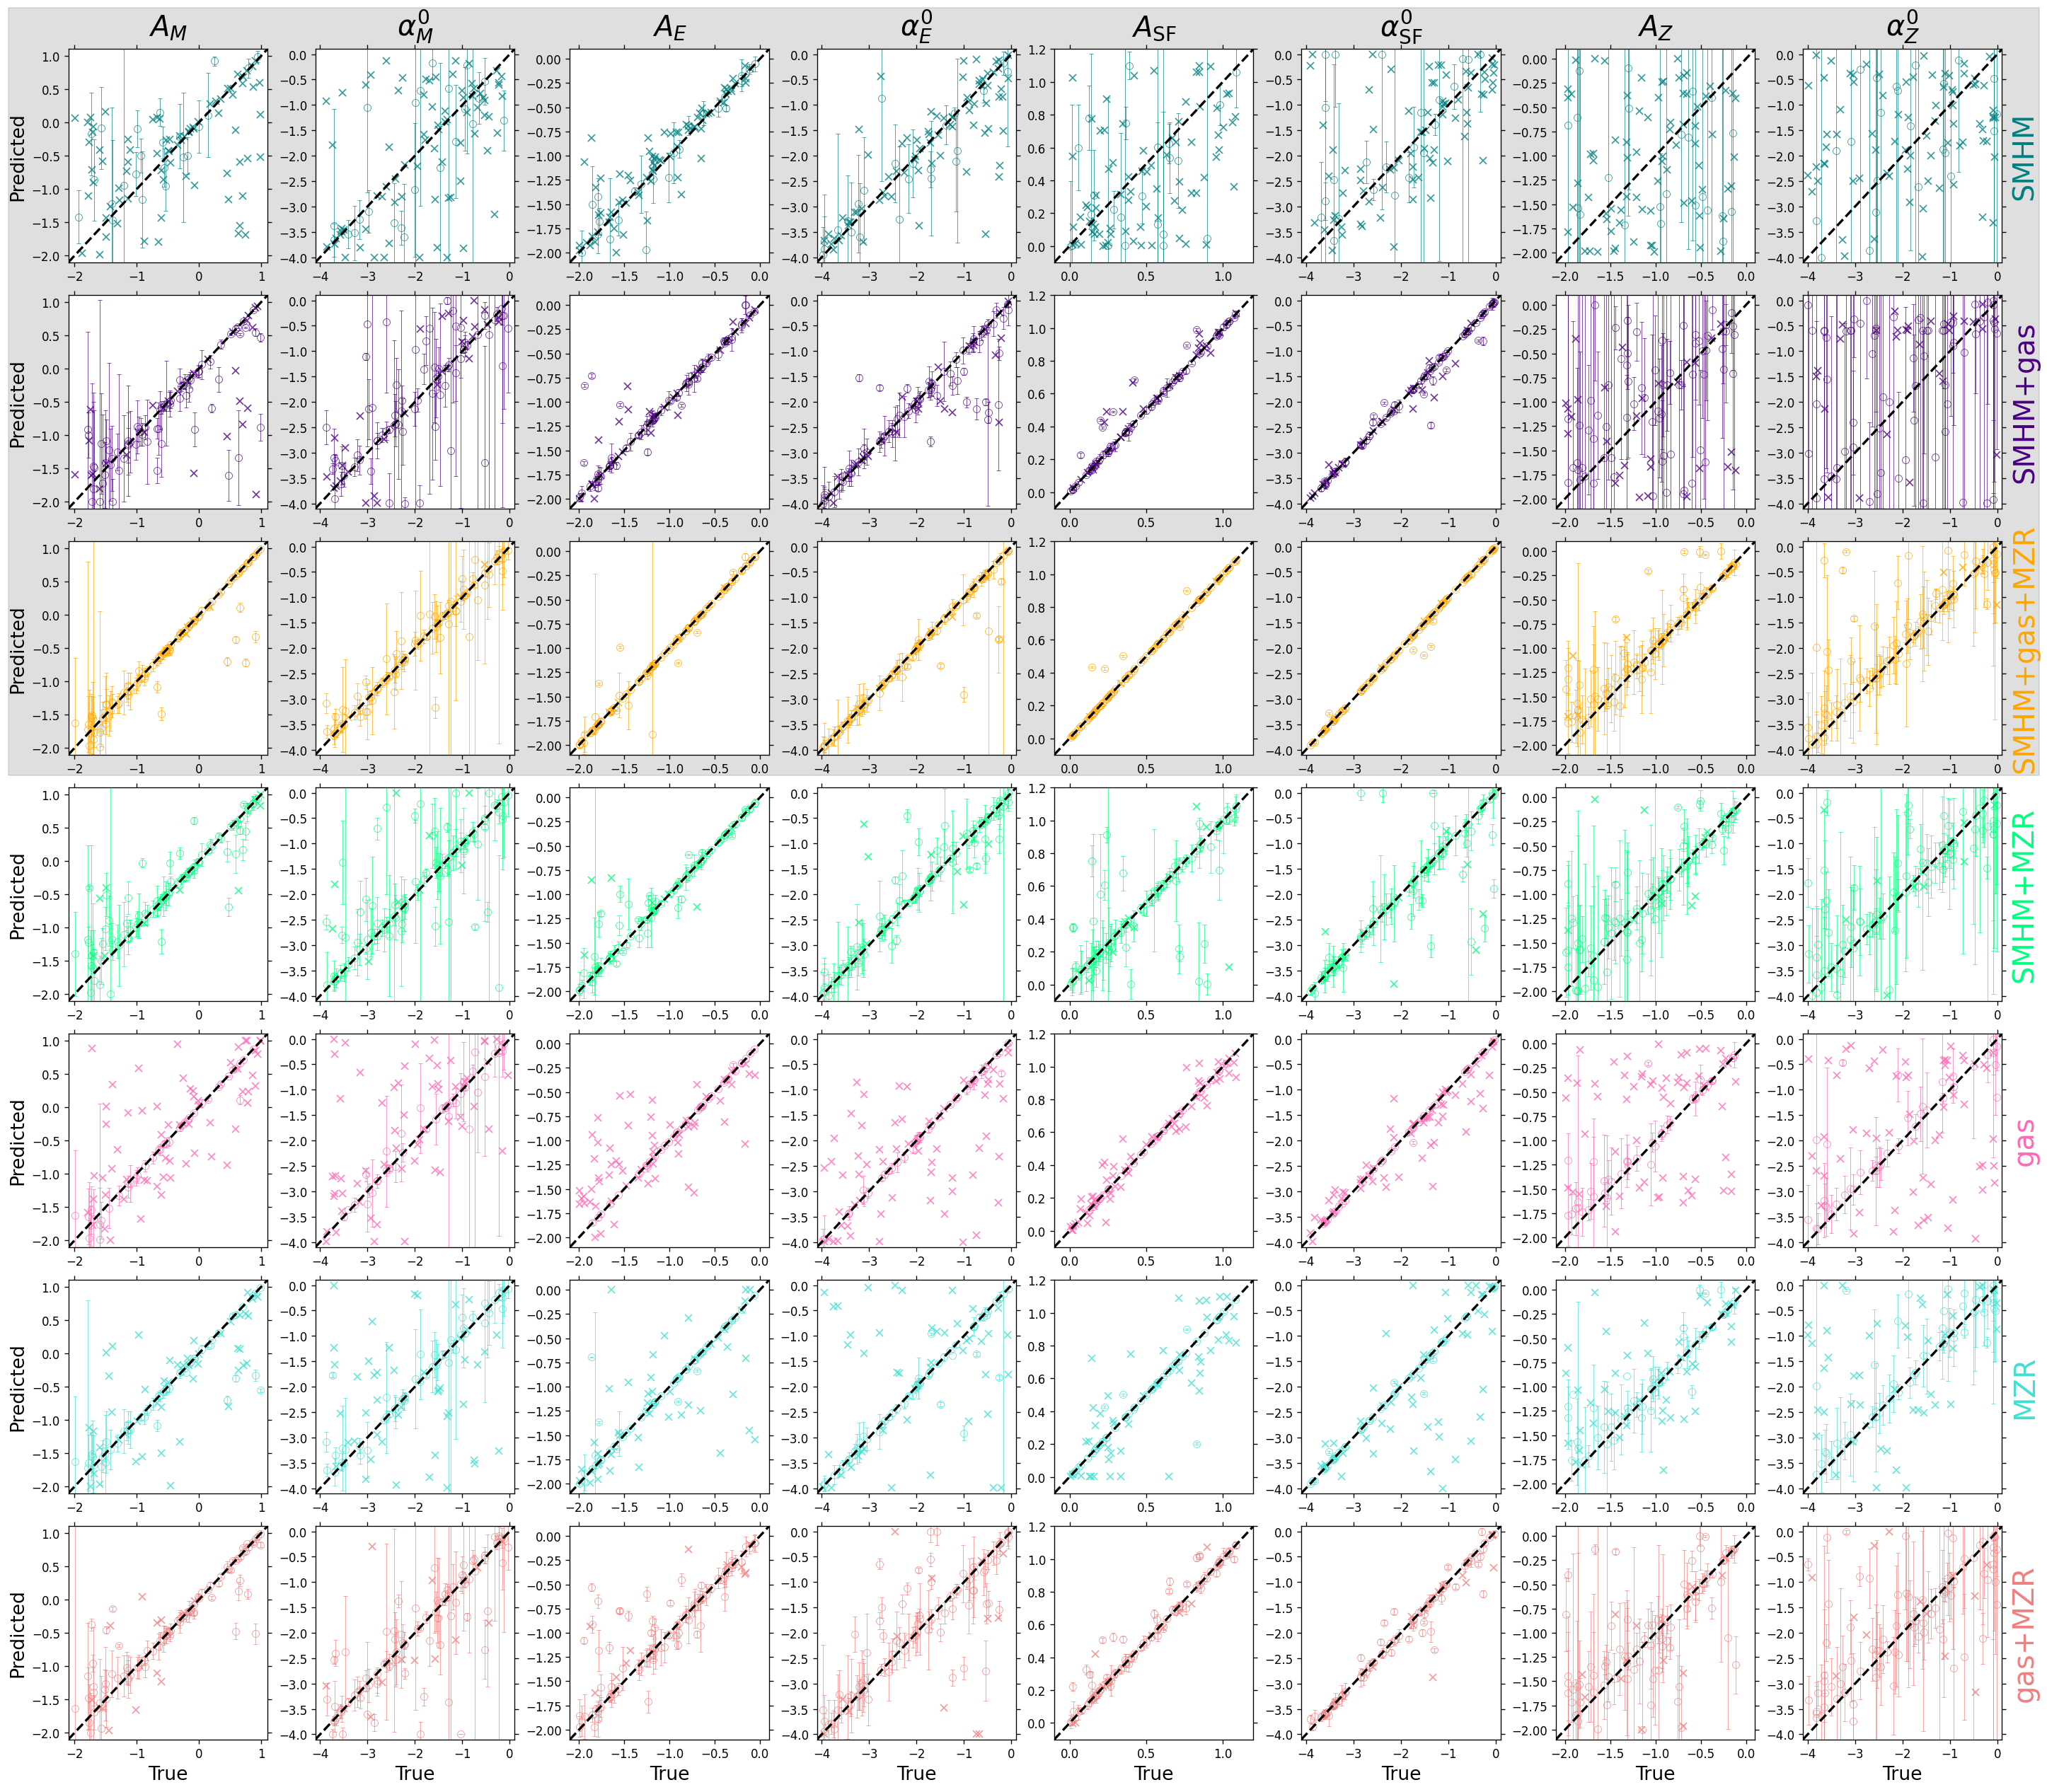

In [9]:
# adapted from https://github.com/maho3/ltu-ili/blob/44522f47c37f69b74313e80c7f1f04600472d116/ili/validation/metrics.py#L471

# TO DO: generalize this based on params_bounds from config.yaml
axlims8 = {0:(-2.1,1.1),1:(-4.1,0.1),2:(-2.1,0.1),3:(-4.1,0.1),4:(-0.1,1.2),5:(-4.1,0.1),6:(-2.1,0.1),7:(-4.1,0.1)}

fig, axes = plt.subplots(nrows=7,ncols=8, figsize=(24, 21),constrained_layout=True)

allax = np.ravel(axes)

out100 = constraint_results[0] # only smhm
out110 = constraint_results[1] # with fgas
out111 = constraint_results[2] # with mzr
out101 = constraint_results[3] # with mzr
out010 = constraint_results[4] # with mzr
out001 = constraint_results[5] # with mzr
out011 = constraint_results[6] # with mzr

# TO DO: generalize this for arbitrary number of parameters
for j in range(8):

    # unpack into mus, truths, sigmas
    mus100 = out100[:, 0, j]
    mus110 = out110[:, 0, j]
    mus111 = out111[:, 0, j]
    mus101 = out101[:, 0, j]
    mus010 = out010[:, 0, j]
    mus001 = out001[:, 0, j]
    mus011 = out011[:, 0, j]
    
    sigmas100 = out100[:, 1, j]
    sigmas110 = out110[:, 1, j]
    sigmas111 = out111[:, 1, j]
    sigmas101 = out101[:, 1, j]
    sigmas010 = out010[:, 1, j]
    sigmas001 = out001[:, 1, j]
    sigmas011 = out011[:, 1, j]

    truths100 = out100[:, 2, j]
    truths110 = out110[:, 2, j]
    truths111 = out111[:, 2, j]    
    truths101 = out101[:, 2, j]
    truths010 = out010[:, 2, j]
    truths001 = out001[:, 2, j]
    truths011 = out011[:, 2, j]
    
    # for points that didn't converge to minimum (non-invertible fisher = nan errorbar) , plot as unfilled marker w/o errorbar
    # this identifies such saddle points by checking whether sigmas is nan (since Fisher = inverse Hessian undefined)
    mask100 = np.isfinite(sigmas100) 
    mask110 = np.isfinite(sigmas110) 
    mask111 = np.isfinite(sigmas111)
    mask101 = np.isfinite(sigmas101)
    mask010 = np.isfinite(sigmas010)
    mask001 = np.isfinite(sigmas001)
    mask011 = np.isfinite(sigmas011)

    # minima w/ fisher errors
    axes[0][j].errorbar(truths100[mask100], mus100[mask100], sigmas100[mask100],
                    fmt="o", elinewidth=0.5, alpha=0.8,color='teal',mfc='none',capsize=2,mew=0.5)
    axes[1][j].errorbar(truths110[mask110], mus110[mask110], sigmas110[mask110],
                        fmt="o", elinewidth=0.5, alpha=0.8,color='indigo',mfc='none',capsize=2,mew=0.5)
    axes[2][j].errorbar(truths111[mask111], mus111[mask111], sigmas111[mask111],
                        fmt="o", elinewidth=0.5, alpha=0.8,color='orange',mfc='none',capsize=2,mew=0.5)

    axes[3][j].errorbar(truths101[mask101], mus101[mask101], sigmas101[mask101],
                        fmt="o", elinewidth=0.5, alpha=0.8,color=constraint_colors[3],mfc='none',capsize=2,mew=0.5)
    axes[4][j].errorbar(truths010[mask010], mus111[mask010], sigmas111[mask010],
                        fmt="o", elinewidth=0.5, alpha=0.8,color=constraint_colors[4],mfc='none',capsize=2,mew=0.5)
    axes[5][j].errorbar(truths001[mask001], mus111[mask001], sigmas111[mask001],
                        fmt="o", elinewidth=0.5, alpha=0.8,color=constraint_colors[5],mfc='none',capsize=2,mew=0.5)
    axes[6][j].errorbar(truths011[mask011], mus011[mask011], sigmas011[mask011],
                        fmt="o", elinewidth=0.5, alpha=0.8,color=constraint_colors[6],mfc='none',capsize=2,mew=0.5)    

    ### non-minima 
    axes[0][j].plot(truths100[~mask100], mus100[~mask100],'x',color='teal',mew=1,alpha=0.8)
    axes[1][j].plot(truths110[~mask110], mus110[~mask110],'x',color='indigo',mew=1,alpha=0.8)
    axes[2][j].plot(truths111[~mask111], mus111[~mask111],'x',color='orange',mew=1,alpha=0.8)
    axes[3][j].plot(truths101[~mask101], mus101[~mask101],'x',color=constraint_colors[3],mew=1,alpha=0.8)
    axes[4][j].plot(truths010[~mask010], mus010[~mask010],'x',color=constraint_colors[4],mew=1,alpha=0.8)
    axes[5][j].plot(truths001[~mask001], mus001[~mask001],'x',color=constraint_colors[5],mew=1,alpha=0.8)
    axes[6][j].plot(truths011[~mask011], mus011[~mask011],'x',color=constraint_colors[6],mew=1,alpha=0.8)

for j in range(8):

    for irow in range(7):
        
        axes[irow][j].plot(
            *(2 * [np.linspace(axlims8[j][0], axlims8[j][1], 10)]),
            'k--', ms=0.2, lw=2,zorder=np.inf)
        # axes[irow][j].set_xlabel('True',fontsize=16)
    
        axes[irow][j].set_xlim(axlims8[j])
        axes[irow][j].set_ylim(axlims8[j])

    axes[0][j].set_title(par_labels[j], fontsize=24,y=1.03)

for irow in range(7):

    axes[irow][-1].yaxis.set_label_position('right')
    axes[irow][-1].set_ylabel(constraint_labels[irow],fontsize=24,color=constraint_colors[irow])

    axes[irow][0].set_ylabel('Predicted',fontsize=16)

for icol in range(8):
    axes[6][icol].set_xlabel('True',fontsize=16)

# Get bounding box of the top 3 rows
fig.canvas.draw()

axs = axes[:3, :].ravel()

# collect tight bounding boxes (includes ticks/labels)
bboxes = [ax.get_tightbbox(fig.canvas.get_renderer()) for ax in axs]

# combine them
bbox = Bbox.union(bboxes)

# convert from display -> figure coordinates
bbox_fig = bbox.transformed(fig.transFigure.inverted())

rect = Rectangle((bbox_fig.x0, bbox_fig.y0),bbox_fig.width,bbox_fig.height,transform=fig.transFigure,
                 color="gray",alpha=0.25,zorder=-1)

fig.add_artist(rect)

outfile = os.path.join(output_path,'figures','coverage_adam_predicted_vs_true_parameters_allcombos.png')
plt.savefig(outfile,bbox_inches='tight',dpi=300,facecolor='w')
print('saved %s'%outfile,flush=True)



In [24]:
def percentile_fishers(sigmas,mus):

    # apply mask 
    mask = np.isfinite(sigmas)
    masked_sigmas = sigmas[mask]

    # March 10 -- normalize parameter value (mu) to get fractional uncertainty
    masked_mus = mus[mask]
    masked_fracs = masked_sigmas / (1+jnp.abs(masked_mus)) # abs value needed since many parameters can be negative 

    # compute percentiles of masked sigmas 
    p16_sigmas = np.nanpercentile(masked_fracs,16,axis=0) 
    p50_sigmas = np.nanpercentile(masked_fracs,50,axis=0) 
    p84_sigmas = np.nanpercentile(masked_fracs,84,axis=0) 
    
    return p16_sigmas, p50_sigmas, p84_sigmas    

def percentile_biases(mus,truths,sigmas_true):

    # accuracy/bias statistic 
    biases = (mus-truths)/(sigmas_true)
    
    # apply mask 
    mask = np.isfinite(sigmas_true) # should always be defined for truth but just in case
    masked_sigmas = sigmas_true[mask]
    masked_biases = biases[mask]
    
    # compute percentiles of masked sigmas 
    p16_biases = np.nanpercentile(masked_biases,16,axis=0)
    p50_biases = np.nanpercentile(masked_biases,50,axis=0)
    p84_biases = np.nanpercentile(masked_biases,84,axis=0)
    
    return p16_biases, p50_biases, p84_biases


def compute_f_fail(out_run):
    sigmas = out_run[:,1,:]
    Nfail = np.sum(~np.all(np.isfinite(sigmas),axis=1))
    return Nfail/len(sigmas)


def fisher_cond(corr_matrices):
    # cond # only computed if an individual realizations' fisher matrix is not nan's (which happens when adam didn't converge to minimum)
    conds = np.asarray([np.linalg.cond(corr_matrices[i]) if np.isfinite(corr_matrices[i]).all() else np.nan for i in range(len(corr_matrices))])
    return np.nanpercentile(conds,16),np.nanpercentile(conds,50),np.nanpercentile(conds,84)




/tmp/ipykernel_1006062/3058531783.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(par_labels, rotation=0,fontsize=12)
/tmp/ipykernel_1006062/3058531783.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(par_labels, rotation=0,fontsize=12)


Text(0.99, 0.8, '16-50-84 percentiles of\nthe condition number of Fisher matrices')

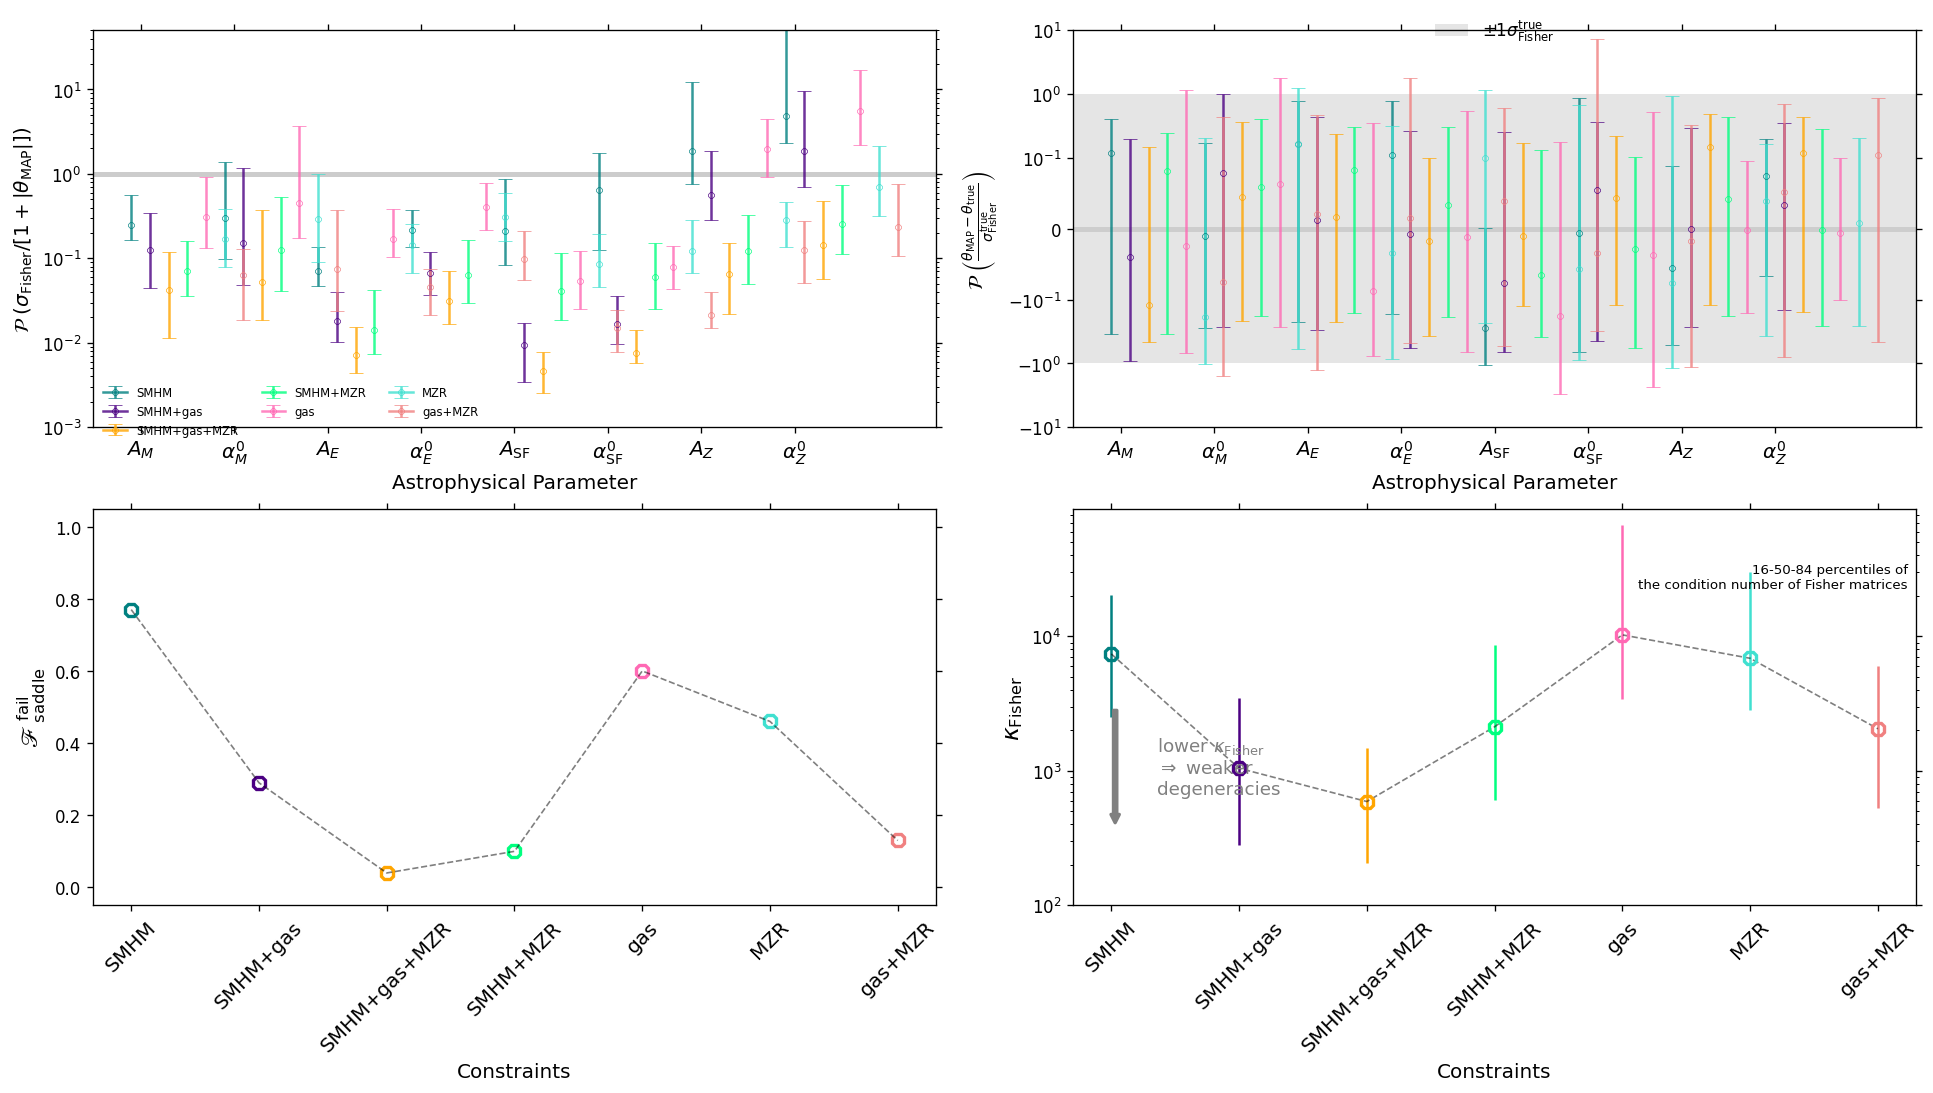

In [34]:
# Define x positions for the labels (parameters)
xvals = np.arange(len(par_labels))
    
### TO DO: automate the figsize for different numbers of constraints/parameters
fig, axes = plt.subplots(nrows=2,ncols=2,figsize=(16,9),constrained_layout=True,dpi=120)

allax = np.ravel(axes)

ax_precision = allax[0]
ax_accuracy = allax[1]
ax_fail = allax[2]
ax_cond = allax[3]

# TO DO: automate this for different # of constraints/parameters (or let user adapt on their own...)
# SMHM, SMHM+fgas, SMHM+fgas+MZR, SMHM+MZR, fgas, MZR, fgas+MZR
constraint_shift = {0: -0.2, 1: 0.0, 2: 0.2, 3:0.4, 4:0.6, 5:0.8, 6:1.0 } 

### precision and accuracy -- loop over each constraint type

for constraint_num, constraint_flag in enumerate(constraint_flags):

    # extract this constraint's stuff
    constraint_result = constraint_results[constraint_num]
    constraint_label = constraint_labels[constraint_num]
    constraint_color = constraint_colors[constraint_num]

    # general x-shift between parameters for precision and accuracy subplots
    shift = constraint_shift[constraint_num] + 0.1

    ### loop over each parameter for precision and accuracy
    for j in range(constraint_result.shape[2]):

        ### precision (sigma_fisher)
        p16, p50, p84 = percentile_fishers(constraint_result[:, 1, j],constraint_result[:, 0, j])
        ax_precision.errorbar(xvals[j] + shift, float(p50),
                              yerr=[[p50 - p16], [p84 - p50]],
                              fmt='-8',color=constraint_color,
                              capsize=4, lw=1.5, alpha=0.8, mfc='none',
                              ms=4, mew=0.5,label=constraint_label if j == 0 else '__none__')

        ### accuracy (bias) 
        p16, p50, p84 = percentile_biases(constraint_result[:, 0, j],constraint_result[:, 2, j],constraint_result[:, 3, j])
        ax_accuracy.errorbar(xvals[j] + shift, float(p50),
                             yerr=[[p50 - p16], [p84 - p50]],
                             fmt='-8',color=constraint_color,
                             capsize=4, lw=1.5, alpha=0.8, mfc='none',
                             ms=4, mew=0.5,label='__none__')

### precision and accuracy subplot labels, limits, etc. 

# first common aesthetics for precision and accuracy
for ax in [ax_precision,ax_accuracy]:

    ax.errorbar(par_labels,np.full(len(par_labels),0),alpha=0)
    ax.set_xticklabels(par_labels, rotation=0,fontsize=12)
    ax.set_xlabel('Astrophysical Parameter',fontsize=12)

ax_precision.axhline(1.0,color='k',lw=3,alpha=0.2,zorder=0,label='__none__')
ax_precision.legend(loc='lower left',fontsize=7,fancybox=True,framealpha=0,ncol=3,bbox_to_anchor=(0,-0.05))
ax_precision.set_ylabel(r'$\mathcal{P}\;\left(\sigma_{\rm Fisher} / [1+|\theta_{\rm MAP}|] \right)$',fontsize=12)
ax_precision.set_yscale('log')
ax_precision.set_ylim(1e-3,5e1)


ax_accuracy.set_ylabel(r'$\mathcal{P}\;\left(\frac{\theta_{\rm MAP}-\theta_{\rm true}}{\sigma_{\rm Fisher}^{\rm true}}\right)$',
                       fontsize=12)
ax_accuracy.set_yscale('symlog',linthresh=1e-1)
ax_accuracy.set_ylim(-10, 10)
ax_accuracy.axhline(0.0, color='k', ls='-', alpha=0.1, zorder=0, lw=3,label='__none__')
ax_accuracy.axhspan(-1,1, facecolor='k', ls='-', alpha=0.1, zorder=0, lw=3,edgecolor='none',
                    label=r'$\pm1\sigma_{\rm Fisher}^{\rm true}$',)
ax_accuracy.legend(loc='upper center',fontsize=10,fancybox=True,framealpha=0,bbox_to_anchor=(0.5,1.07))


### failure (saddle) rate
constraint_f_fail = [compute_f_fail(constraint_results[i]) for i in range(len(constraint_results))]

for constraint_num,constraint_color in enumerate(constraint_colors):

    ax_fail.plot(constraint_labels[constraint_num],constraint_f_fail[constraint_num],'8',
                 color=constraint_color,mfc='none',ms=8,mew=2)

ax_fail.plot(list(constraint_labels),constraint_f_fail,'k--',lw=1,alpha=0.5) 

ax_fail.set_ylim(-0.05,1.05)
ax_fail.set_ylabel(r'$\mathscr{F}_{\rm \;saddle}^{\rm \;fail}$',fontsize=14)
ax_fail.set_xlabel('Constraints',fontsize=12)
ax_fail.tick_params(axis='x',labelsize=12,labelrotation=45)

### degeneracy strength (fisher matrix condition number)
constraint_conds = [fisher_cond(constraint_corrs[i]) for i in range(len(constraint_corrs))]

for constraint_num, constraint_color in enumerate(constraint_colors):

    cond = constraint_conds[constraint_num]

    ax_cond.errorbar(constraint_labels[constraint_num], cond[1],
                     yerr=[[cond[1]-cond[0]], [cond[2]-cond[1]]],
                     fmt='8', color=constraint_color, mfc='none', ms=8, mew=2)

ax_cond.plot(constraint_labels,[constraint_conds[i][1] for i in range(7)],'k--',lw=1,alpha=0.5) # July 8
ax_cond.tick_params(axis='x',labelsize=12,labelrotation=45)

ax_cond.set_ylabel(r'$\kappa_{\rm Fisher}$', fontsize=14)
ax_cond.set_xlabel('Constraints', fontsize=12)
ax_cond.set_yscale('log')
ax_cond.set_ylim(1e2,None)

# Add a thick downward arrow using ax.arrow
ax_cond.annotate('', xy=(0.05, 0.2), xytext=(0.05, 0.5), xycoords='axes fraction',
                 arrowprops=dict(arrowstyle='simple', color='gray', lw=2,))

# Add the text to the right of the arrow
ax_cond.text(0.1, 0.35,r'lower $\kappa_{\rm Fisher}$' + '\n' + r'$\Rightarrow$ weaker' + '\n' + r'degeneracies',
             transform=ax_cond.transAxes,fontsize=11, color='gray', va='center')

ax_cond.text(0.99,0.8,'16-50-84 percentiles of\nthe condition number of Fisher matrices',
             transform=ax_cond.transAxes,fontsize=8,ha='right')

